# Week 2 Assignment — Celebal Technologies (DS Internship)


Dataset Link :- [Tesla_Cars_Sales_&_Production](https://www.kaggle.com/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025)

Goal :- Designed and implemented an end-to-end ML pipeline on sales/price data covering preprocessing, EDA, feature engineering, regression modeling, hyperparameter tuning, and time series forecasting.

### Setup 

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


In [3]:
df=pd.read_csv("C:/Studies/Celebal_Internship/tesla_deliveries_dataset_2015_2025.csv")

### Exploration/Inspection

In [4]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [25]:
df.shape

(2640, 12)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [ ]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [28]:
df.duplicated().sum()

0

In [29]:
df.sample(5)

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
1148,2022,2,Europe,Cybertruck,15018,15865,115982.68,120,709,1597.16,Estimated (Region),10052
1112,2025,8,Asia,Cybertruck,14792,14834,57854.10,120,719,1595.32,Estimated (Region),6364
382,2015,9,North America,Model Y,7812,8720,81730.22,100,576,674.96,Estimated (Region),8289
370,2025,4,North America,Model X,8085,8158,66600.37,100,571,692.48,Official (Quarter),11766
1344,2018,10,Europe,Model S,10672,11272,93493.14,120,703,1125.36,Official (Quarter),4327


### Findings : By looking at the data ->
####      5 Categorical and 7 numeical columns are seen

### Checking data
#### Since it is from kaggle so most probably might be Cleaned, Artifically Symmetric, etc. But still checking

In [22]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

### no missing values (as expected)

# Categorical columns analysis

<Axes: ylabel='count'>

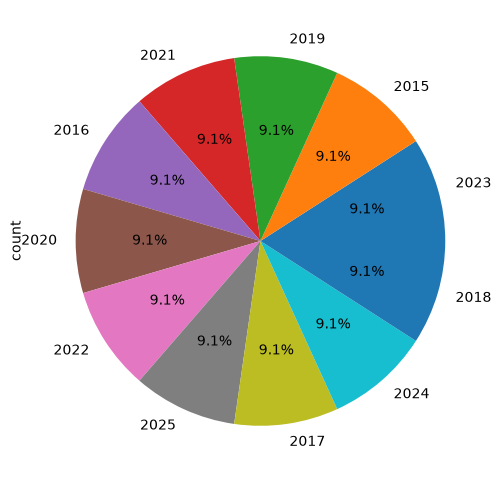

In [15]:
df["Year"].value_counts().plot(kind="pie", autopct="%1.1f%%", figsize=(6, 6))

In [ ]:
categorical_cols = ["Year", "Month", "Region", "Model", "Source_Type"]

for col in categorical_cols:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts())


Value counts for Year:
Year
2023    240
2015    240
2019    240
2021    240
2016    240
2020    240
2022    240
2025    240
2017    240
2024    240
2018    240
Name: count, dtype: int64

Value counts for Month:
Month
5     220
2     220
1     220
12    220
4     220
11    220
6     220
3     220
10    220
7     220
9     220
8     220
Name: count, dtype: int64

Value counts for Region:
Region
Europe           660
Asia             660
North America    660
Middle East      660
Name: count, dtype: int64

Value counts for Model:
Model
Model S       528
Model X       528
Model 3       528
Model Y       528
Cybertruck    528
Name: count, dtype: int64

Value counts for Source_Type:
Source_Type
Interpolated (Month)    884
Official (Quarter)      884
Estimated (Region)      872
Name: count, dtype: int64


### Only one category is non-uniform (very little difference still)
Interpolated (Month)    884

Official (Quarter)      884

Estimated (Region)      872
